In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split

## Splitting demos

A brief example of sampling bias

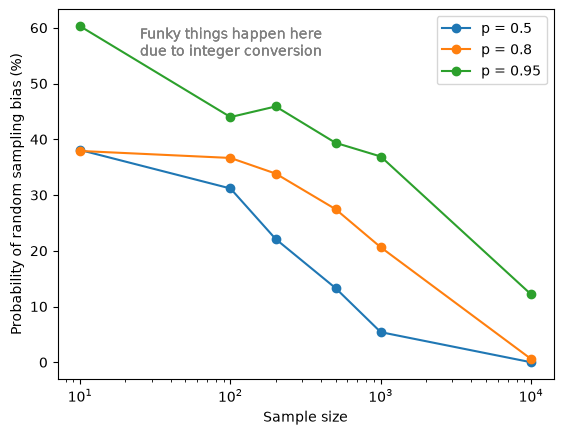

For p = 0.95
Sample size 10: Bias = 60.3% chance of sampling < 9.5 or > 9.5
Sample size 100: Bias = 44.0% chance of sampling < 94.8 or > 95.2
Sample size 200: Bias = 45.9% chance of sampling < 189.5 or > 190.5
Sample size 500: Bias = 39.4% chance of sampling < 473.8 or > 476.2
Sample size 1000: Bias = 36.9% chance of sampling < 947.5 or > 952.5
Sample size 10000: Bias = 12.2% chance of sampling < 9475.0 or > 9525.0


In [33]:
from scipy.stats import binom
import matplotlib.pyplot as plt

p = 0.8 # ratio of likes cilantro to dislikes cilantro
buffer = 0.05 # plus/minus 5%
sample_sizes = [10, 100, 200, 500, 1000, 10000]

for p in [0.5, 0.8, 0.95]:
    prob_bias = []
    for n in sample_sizes:
        # compute the buffer size relative to the underrepresented class
        small_buffer = (buffer * n * (1 - p))
        too_small = n * p - small_buffer
        too_large = n * p + small_buffer
        prob_bias.append(binom(n, p).cdf(too_small) + (1 - binom(n, p).cdf(too_large)) * 100)

    plt.plot(sample_sizes, prob_bias, "o-", label=f"p = {p}")
    plt.xlabel("Sample size")
    plt.ylabel("Probability of random sampling bias (%)")
    plt.xscale("log")
    plt.text(25, 55, "Funky things happen here\ndue to integer conversion", color="grey")

plt.legend()
plt.show()

print("For p = 0.95")
for n, b in zip(sample_sizes, prob_bias):
    small_buffer = (buffer * n * (1 - p))
    too_small = n * p - small_buffer
    too_large = n * p + small_buffer
    print(f"Sample size {n}: Bias = {b:.1f}% chance of sampling < {too_small:.1f} or > {too_large:.1f}")


Sampling with updated data: random vs feature hashing

Train: [8 9 7 4 6 2 0 3]
Test:  [1 5]


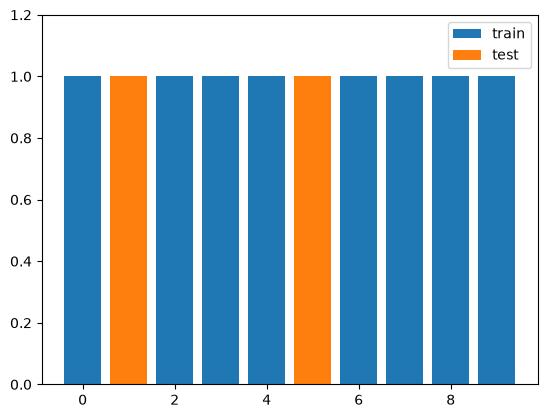

In [16]:
# create random number generator
rng = np.random.default_rng(seed=42)

N = 10

ids = np.arange(N)
train = rng.choice(ids, N * 8 // 10, replace=False)
test = np.delete(ids, train)

print("Train:", train)
print("Test: ", test)

plt.bar(train, np.ones_like(train), label="train")
plt.bar(test, np.ones_like(test), label="test")
plt.ylim([0,1.2])
plt.legend()

[1696784233 2844319735  654825492 3954038922 3781742995  767742221
 2739787502 1877464688 3066545372 2054014018 4108501921  944292671
  848153126 4264020664 1890110811 3154300357  429518402 3576950492
 1539107135 2534861217]
Train: [ 0  1  2  5  6  7  8  9 11 12 14 15 16 18 19]
Test:  [ 3  4 10 13 17]


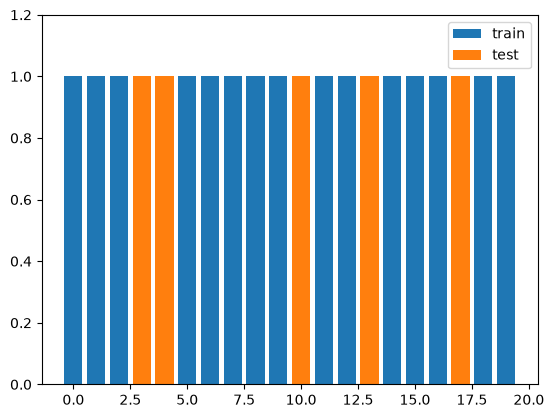

In [14]:
# deterministic approach: hashing
from zlib import crc32

# 80% of the maximum possible 32-bit hash value
test_thresh = 0.8 * 2**32

N = 20

ids = np.arange(N)
hash_vals = np.array([crc32(id) for id in ids])
train = ids[hash_vals < test_thresh]
test = np.delete(ids, train)

print(hash_vals)
print("Train:", train)
print("Test: ", test)

plt.bar(train, np.ones_like(train), label="train")
plt.bar(test, np.ones_like(test), label="test")
plt.ylim([0,1.2])
plt.legend()

## Titanic Example

In [ ]:
# Load the titanic data again
td = pd.read_csv("../03_eda/titanic_train.csv")

In [ ]:
# Splitting the data - random sample
# at minimum, needs random seed for consistency
td_train, td_test = train_test_split(td, test_size=0.2, random_state=1234)

In [ ]:
# Check the ratios
print(td_train["Sex"].value_counts() / len(td_train))
print(td_test["Sex"].value_counts() / len(td_test))

In [ ]:
# Splitting the data - stratified sample
# Want to make sure equal ratios of sex in train and test
# TODO: split with stratification

In [ ]:
# scatter plots
# Is there a relationship between age/fare and survival?
ax = td_train.plot.scatter(x="Age", y="Fare", c="Survived", cmap="viridis", alpha=0.3)

In [ ]:
# maybe a log scale would help?
# TODO: set_yscale to log

In [ ]:
# box plots
ax = td_train.boxplot(by="Survived", column="Fare")
# TODO: set_yscale to log

In [ ]:
x = td_train["Survived"]
y = td_train["Fare"]
# plt.scatter(x, y, alpha=0.3)

# add jitter
rng = np.random.default_rng(seed=1234)
jitter = rng.normal(size=x.shape, scale=0.1)
fig, ax = plt.subplots(1)
ax.scatter(x+jitter, y, alpha=0.3)
ax.set_yscale("log")

## Combining data

Data usually comes from different sources. For example, let's say I want to find the temperature closest to a given road incident.

Climate data source: https://collaboration.cmc.ec.gc.ca/cmc/climate/Get_More_Data_Plus_de_donnees/Command_Lines_EN.txt

Traffic data source: https://data.calgary.ca/Transportation-Transit/Traffic-Incidents/35ra-9556/about_data

In [ ]:
# %%bash
# for month in `seq 1 12`; do wget --content-disposition "https://climate.weather.gc.ca/climate_data/bulk_data_e.html?format=csv&climate_id=3031092&Year=2025&Month=${month}&Day=14&timeframe=1&submit=Download+Data" ;done

In [ ]:
from pathlib import Path

dfs = []
for csv in Path(".").glob("en_climate*.csv"):
    dfs.append(pd.read_csv(csv))

climate = pd.concat(dfs, axis=0)

In [ ]:
climate.info()

In [ ]:
incidents = pd.read_csv("Traffic_Incidents_20260928.csv")

In [ ]:
incidents.info()

In [ ]:
# inspect the date formats
print(climate["Date/Time (LST)"].iloc[0])
print(incidents["START_DT_UTC"].iloc[0])


In [ ]:
# convert both datetime values to actual datetime objects
climate["DT"] = pd.to_datetime(climate["Date/Time (LST)"]).astype("datetime64[s]")
incidents["DT"] = (pd.to_datetime(incidents["START_DT_UTC"]) - pd.Timedelta("6 hours")).astype("datetime64[s]")

In [ ]:
# close enough, doesn't account for Standard time in summer though
incidents["DT"].iloc[0]

In [ ]:
# check that that worked
plt.scatter(climate["DT"], climate["Temp (°C)"])

In [ ]:
plt.hist(incidents["DT"], bins=12)

In [ ]:
incidents.sort_values(by="DT", ascending=True, inplace=True)
df = pd.merge_asof(incidents, climate, on="DT", direction="nearest")

In [ ]:
df.aggregate()

In [ ]:
bins = np.arange(-30, 30, 2)
climate["Temp (°C)"].hist(density=True, bins=bins, label="2025 temperature distribution")
# df["Temp (°C)"].hist(density=True, bins=bins, label="2025 traffic incidents")
plt.legend()